# Dashboard plot inspection
Reuses the real pipeline (`load_traces` → `derive_trace_metrics` → phase filter) and draws plain lines so the plotted values can be read directly. The knobs cell mirrors the sidebar Graph settings.

In [ ]:
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "app" else Path("/home/omulkin/gaia/boss")
sys.path.insert(0, str(ROOT))

from app.plotting.traces import load_traces, derive_trace_metrics
from app.analysis.results_summary import _apply_phase_filter, _phase_options
from app.analysis.cboss_diagnostics import generate_cboss_diagnostics, has_cboss_diagnostics
from app.phases import INIT_PHASES

In [2]:
# --- hard-coded run + selection ---
RUN = "base_experiment_tnss"

cfg = json.loads((ROOT / "artifacts" / "runs" / RUN / "config.json").read_text())
SEEDS = cfg["seeds"]
CONFIGS = [(c["config_id"], c["label"]) for c in cfg["algo_configs"]]

# Only (seed, config) combos that actually have a traces.csv — a partially-run
# config (e.g. added via Extend) is absent for some seeds, like the dashboard table.
def _sub(c):
    return f"{c['config_id']}_{c['policy'].replace('-', '_')}"
keys = [(RUN, s, c["config_id"]) for c in cfg["algo_configs"] for s in SEEDS
        if (ROOT / "artifacts/runs" / RUN / f"seed_{s}" / _sub(c) / "traces.csv").exists()]

# Full (un-derived) frame; the plot cells re-derive from this under the current knobs.
raw = load_traces(ROOT, keys, derive=False)

# Dashboard default phase selection: hide the init phase (display-only filter).
PHASES = _phase_options(raw["phase"])
SELECTED = [p for p in PHASES if p not in INIT_PHASES] or PHASES

print(RUN, "| problem:", cfg["problem_id"], "| seeds:", SEEDS)
print("phases:", PHASES, "-> shown:", SELECTED)
for cid, lab in CONFIGS:
    print("  ", cid, lab)

2026-06-07 18:57:49.528 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-06-07 18:57:49.533 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


base_experiment_tnss | problem: synth_fctn_5c_2_to_8_fixedadj_71ce | seeds: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
phases: ['init', 'interpolation', 'bo', 'main'] -> shown: ['interpolation', 'bo', 'main']
   af53 boss_ei_input_warp
   c960 cboss_cei_warp
   d65b cboss_ficr_warp
   98e4 tnale
   3eed boss_ucb
   5815 tnale_id5815


In [3]:
# --- sidebar knobs (Graph settings) ---
BEST_BY        = "objective"   # "objective" | "feasible_cr"  (incumbent definition)
LOSS_THRESHOLD = float("inf")  # RSE feasibility cutoff (used when BEST_BY == feasible_cr)
USE_EFFICIENCY = False         # CR metric: False = compression ratio, True = efficiency (synthetic only)
WEIGHT_RSE     = True          # RSE term: True = lambda*RSE, False = raw RSE
SEED           = 1             # which seed the Performance cell plots

CR_COL = "inc_efficiency" if USE_EFFICIENCY else "inc_cr"

def derive(frame):
    """Same derivation + phase filter the dashboard applies before plotting."""
    d = derive_trace_metrics(frame, best_by=BEST_BY, feasible_threshold=LOSS_THRESHOLD)
    return _apply_phase_filter(d, SELECTED)

def draw(frame, title_prefix):
    """Three panels (objective, CR/efficiency, RSE) — mean over whatever seeds are in `frame`."""
    rse_title = "lambda*RSE" if WEIGHT_RSE else "RSE"
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for cid, lab in CONFIGS:
        sel = frame[frame["config_id"] == cid]
        if sel.empty:
            continue
        lam = float(sel["lambda_fitness"].iloc[0]) if WEIGHT_RSE else 1.0
        g = sel.groupby("n_evals")
        series = [g["objective"].mean(), g[CR_COL].mean(), g["inc_rse"].mean() * lam]
        for ax, s in zip(axes, series):
            ax.plot(s.index, s.values, marker=".", ms=3, label=lab)
    for ax, t in zip(axes, ["objective", CR_COL, rse_title]):
        ax.set_title(f"{title_prefix} · {t}"); ax.set_xlabel("n_evals")
    axes[0].legend(fontsize=8)
    plt.tight_layout(); plt.show()

In [8]:
raw

,step,phase,objective,cr,rse,target_cr,step_time_s,run,config_id,label,policy,family,lambda_fitness,seed
0,0,init,9.852481,0.015816,9.836664e-01,2.987755,0.946689,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,10.0,1
1,1,init,9.851610,0.023980,9.827631e-01,2.987755,0.627792,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,10.0,1
2,2,init,9.662832,0.034949,9.627883e-01,2.987755,0.709276,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,10.0,1
3,3,init,9.334721,0.061735,9.272986e-01,2.987755,0.737583,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,10.0,1
4,4,init,9.141004,0.077296,9.063708e-01,2.987755,0.759029,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,10.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22426,673,main,1.111344,1.101786,9.558474e-04,2.987755,1.594001,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,10.0,8
22427,674,main,1.297196,1.297194,2.437029e-07,2.987755,1.623659,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,10.0,8
22428,675,main,1.132387,1.056888,7.549944e-03,2.987755,1.560957,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,10.0,8
22429,676,main,1.107739,1.101786,5.952966e-04,2.987755,1.554159,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,10.0,8


In [5]:
df = derive(raw)

In [6]:
df

,run,config_id,label,policy,family,seed,phase,n_evals,objective,cr,rse,efficiency,inc_cr,inc_rse,inc_efficiency,inc_cum_time_s,target_cr,step_time_s,cum_time_s,lambda_fitness
19,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,1,init,20,1.332148,33.489796,2.188351e-06,0.089214,1.332143,4.890518e-07,2.242819,11.339528,2.987755,3.647775,26.537949,10.0
20,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,1,bo,21,1.332148,3.716327,1.220696e-06,0.803954,1.332143,4.890518e-07,2.242819,11.339528,2.987755,2.314187,28.852136,10.0
21,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,1,bo,22,1.332148,3.190816,5.901915e-01,0.936361,1.332143,4.890518e-07,2.242819,11.339528,2.987755,1.776506,30.628642,10.0
22,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,1,bo,23,1.332148,0.768367,1.903520e-01,3.888446,1.332143,4.890518e-07,2.242819,11.339528,2.987755,1.849438,32.478081,10.0
23,base_experiment_tnss,af53,boss_ei_input_warp,boss-ei,boss,1,bo,24,1.332148,0.680612,2.614921e-01,4.389805,1.332143,4.890518e-07,2.242819,11.339528,2.987755,1.915140,34.393221,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22426,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,8,main,673,1.105435,1.101786,9.558474e-04,2.711739,1.101786,3.648949e-04,2.711739,747.648719,2.987755,1.594001,1021.737335,10.0
22427,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,8,main,674,1.105435,1.297194,2.437029e-07,2.303245,1.101786,3.648949e-04,2.711739,747.648719,2.987755,1.623659,1023.360994,10.0
22428,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,8,main,675,1.105435,1.056888,7.549944e-03,2.826937,1.101786,3.648949e-04,2.711739,747.648719,2.987755,1.560957,1024.921951,10.0
22429,base_experiment_tnss,5815,tnale_id5815,tnale,tnale,8,main,676,1.105435,1.101786,5.952966e-04,2.711739,1.101786,3.648949e-04,2.711739,747.648719,2.987755,1.554159,1026.476110,10.0


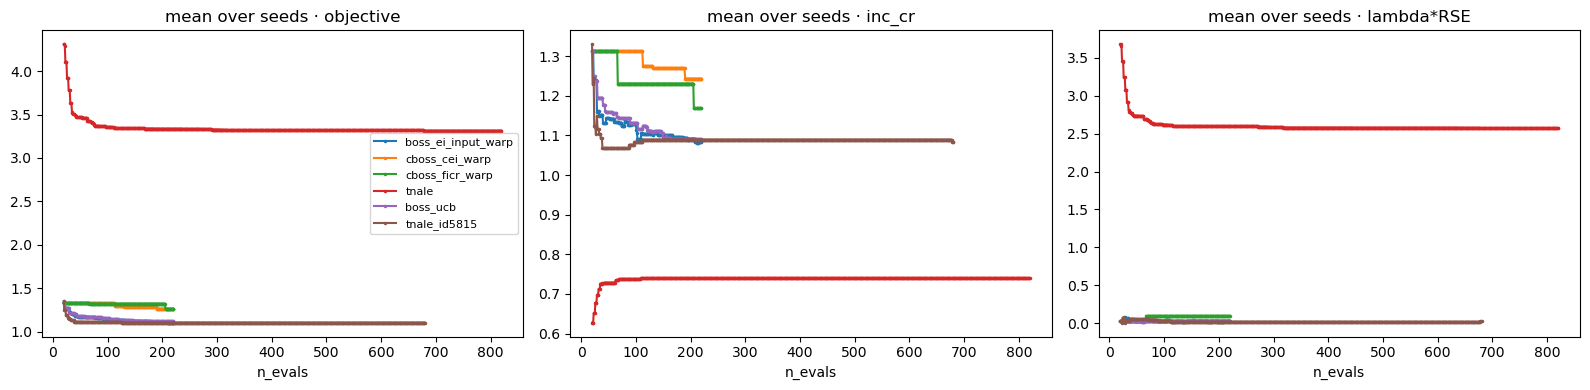

In [7]:
# --- Results Summary: mean over all seeds, one line per config ---

draw(df, "mean over seeds")

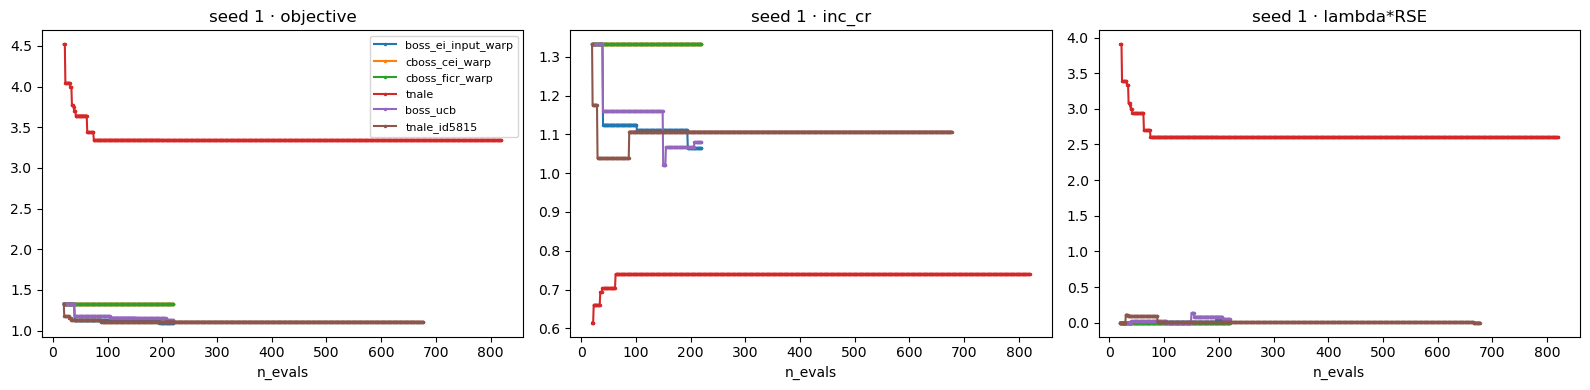

In [5]:
# --- Performance: a single seed, no averaging ---
df1 = derive(raw[raw["seed"] == SEED])
draw(df1, f"seed {SEED}")

## Surrogate diagnostics (cBOSS feasibility classifier)
Built from the run's saved artifacts (traces, `cboss_results.npz`, `gp_states.pt`) — no GP retrain. Figures are cached under the config's `analysis/cboss/` folder.

In [ ]:
# --- generate (or load cached) cBOSS feasibility-classifier diagnostics ---
DIAG_CID  = next(c["config_id"] for c in cfg["algo_configs"] if c["family"] == "cboss")
DIAG_SEED = 1
dcfg = next(c for c in cfg["algo_configs"] if c["config_id"] == DIAG_CID)
cd = ROOT / "artifacts/runs" / RUN / f"seed_{DIAG_SEED}" / _sub(dcfg)

if not has_cboss_diagnostics(cd):  # builds the figures from run artifacts (no GP retrain)
    generate_cboss_diagnostics(cd)
diag_dir = cd / "analysis" / "cboss"
pngs = sorted(diag_dir.glob("*.png"))
print(dcfg["label"], "| seed", DIAG_SEED, "| figures:", [p.stem for p in pngs])

In [ ]:
# --- show the generated cBOSS diagnostic figures ---
for p in pngs:
    print(p.stem)
    display(Image(filename=str(p)))